# **Shot Volume or Shot Quality? A Machine Learning Approach to Explaining Expected Goals in Football**

---

## Contents

<hr style="border:none;border-top:1px solid #e5e7eb;width:50%;margin:12px 0 16px 0;">

**1 - Introduction**

<hr style="border:none;border-top:1px solid #e5e7eb;width:50%;margin:12px 0 16px 0;">

**2 - Background**

<hr style="border:none;border-top:1px solid #e5e7eb;width:50%;margin:12px 0 16px 0;">

**3 - Data Preparation**
- **3.1 - Importing**
- **3.2 - Inspecting**
- **3.3 - Cleaning**
- **3.4 - Feature Engineering**
- **3.5 - Dataset Validation**

<hr style="border:none;border-top:1px solid #e5e7eb;width:50%;margin:12px 0 16px 0;">

**4 - Exploratory Data Analysis (EDA)**
- **4.1 - Shot Types vs xG**
    - **4.1.1 - Home**
    - **4.1.2 - Away**
    - **4.1.3 - Validating Scatter Shapes**
- **4.2 - Home vs Away**
    - **4.2.1 - xG**
    - **4.2.2 - Shot Types**
- **4.3 - xG per Shot**

<hr style="border:none;border-top:1px solid #e5e7eb;width:50%;margin:12px 0 16px 0;">

**5 - Modelling**
- **5.1 - Train/Test Split**
- **5.2 - Model Function**
- **5.3 - Game Total Shots >>> Game xG**
- **5.4 - Game Shot Metrics >>> Game xG**
- **5.5 - Game Shot Metrics + Game Shot Situations >>> Game xG**
- **5.6 - Home Shot Metrics + Home Shot Situations >>> Home xG**
- **5.7 - Away Shot Metrics + Away Shot Situations >>> Away xG**
- **5.8 - Comparison & Evaluation**




<hr style="border:none;border-top:1px solid #e5e7eb;width:50%;margin:12px 0 16px 0;">

**6 - Conclusion**

<hr style="border:none;border-top:1px solid #e5e7eb;width:50%;margin:12px 0 16px 0;">

**Appendix**

<hr style="border:none;border-top:1px solid #e5e7eb;width:50%;margin:12px 0 16px 0;">

---

## 1 - Introduction

Expected goals (xG) has become the standard measure of attacking performance in football, but it is a composite quantity: a team's xG for a match is the sum of the individual scoring probabilities of every shot they took. It therefore depends on two distinct things - **how many shots a team took**, and **how good those shots were**.

This project asks how much of a team's xG is explained by shot volume alone. If shot counts account for most of the variation, then xG carries little information beyond simply counting attempts. If they do not, then the remainder must come from chance quality, and the analysis can go on to identify which characteristics of a shot drive that difference.

Two breakdowns are used to test this. Each shot is classified by its **outcome** - on target, off target, or blocked - and by the **situation it arose from**, whether open play, a corner, a set piece, a direct free kick, or a penalty. Models are then built in stages, beginning with total shots alone and adding each breakdown in turn, so that the contribution of every piece of information can be measured separately.

Starting from raw event-level data covering more than half a million shots, the data is cleaned, aggregated to match level, and validated against a separate match-level dataset. The relationships between shot metrics and xG are then explored visually before being modelled with both Linear Regression and a Random Forest, compared on R^2, mean absolute error and root mean squared error.

---

## 2 - Background

The use of data to predict outcomes in football is not a new concept. That said, it was not the first sport to turn to it. Analytics in professional sport was originally pioneered and popularised in baseball through the development of sabermetrics, demonstrating that statistical analysis could uncover valuable insights that were often overlooked by traditional scouting methods. Popularised by _Moneyball_, this approach showed that data-driven decision making could provide a significant competitive advantage and laid the foundation for modern sports analytics.

Some would argue that football presents a harder problem than baseball. Goals are rare and heavily influenced by chance, so a single match result is a noisy measure of how well a team actually played. Expected goals solves this somewhat. Each shot is assigned a probability of becoming a goal based on the circumstances in which it was taken. Summing these probabilities across a match gives a measure of chance creation that is far less noisy than the scoreline.

Because xG is constructed as a sum over shots, it can be written exactly as:

$$
\text{xG} = N \times \bar{q}
$$

where $N$ is the number of shots taken and $\bar{q}$ is their average scoring probability. This breakdown is the basis of the project. The two terms describe genuinely different aspects of attacking play: $N$ reflects how often a team manufactures a shooting opportunity, while $\bar{q}$ reflects how dangerous those opportunities are. A side that takes many speculative efforts from distance and one that engineers a handful of clear chances can record similar shot counts and very different xG.

A shot that reached the goal is not equivalent to one that was blocked in a crowd of defenders, and a penalty is not equivalent to a speculative effort from a corner. The dataset records both the outcome of every shot and the situation it arose from, which allows a team's shots to be broken down rather than simply counted. If shot quality contributes meaningfully to xG, these breakdowns should explain variation that total shots alone cannot.

The question of which term dominates has practical consequences. If xG is largely a function of volume, then shot counts and expected goals convey much the same information, and the simpler measure is sufficient. If quality contributes substantially, then the composition of a team's shots matters independently of how many they take, and any analysis based on shot counts alone is incomplete. This project quantifies that split and examines which shot characteristics account for the difference.

---

## 3 - Data Preparation

### 3.1 - Importing

In [1]:
# Import Modules

# General use
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Modelling
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import skellam

In [2]:
# Import dataset and assign to dataframe 'events'
events = pd.read_csv("game_events.csv")

### 3.2 - Inspecting

In [3]:
# Count number of columns and rows
print("Number of columns = " + str(len(events.columns)))
print("Number of rows = " + str(len(events)))

Number of columns = 20
Number of rows = 518876


In [4]:
# Inspect first 5 rows
events.head()

,id,minute,result,X,Y,xG,player,h_a,player_id,situation,season,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction
0,545909,27,BlockedShot,0.794,0.421,0.104347,Juan Mata,h,554,DirectFreekick,2015,LeftFoot,81,Manchester United,Tottenham,1,0,2015-08-08 15:45:00,NaN,Standard
1,545910,27,BlockedShot,0.860,0.627,0.064342,Memphis Depay,h,555,SetPiece,2015,RightFoot,81,Manchester United,Tottenham,1,0,2015-08-08 15:45:00,Ashley Young,Pass
2,545911,35,BlockedShot,0.843,0.333,0.057157,Juan Mata,h,554,OpenPlay,2015,LeftFoot,81,Manchester United,Tottenham,1,0,2015-08-08 15:45:00,Wayne Rooney,Pass
3,545912,35,MissedShots,0.848,0.533,0.092141,Juan Mata,h,554,OpenPlay,2015,LeftFoot,81,Manchester United,Tottenham,1,0,2015-08-08 15:45:00,NaN,Tackle
4,545913,40,BlockedShot,0.812,0.707,0.035742,Memphis Depay,h,555,OpenPlay,2015,RightFoot,81,Manchester United,Tottenham,1,0,2015-08-08 15:45:00,Michael Carrick,BallRecovery


In [5]:
# Key metrics of each column
events.describe()

,id,minute,X,Y,xG,player_id,season,match_id,h_goals,a_goals
count,518876.000000,518876.000000,518876.000000,518876.000000,518876.000000,518876.000000,518876.000000,518876.000000,518876.000000,518876.000000
mean,296137.017156,48.690126,0.844777,0.504335,0.109218,3844.422849,2018.542224,11530.020965,1.579402,1.258231
std,178464.853211,26.662393,0.090324,0.128092,0.161396,3116.371213,2.901638,6900.919975,1.331807,1.182754
min,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2014.000000,81.000000,0.000000,0.000000
25%,129898.750000,26.000000,0.782000,0.415000,0.024175,1248.000000,2016.000000,5421.000000,1.000000,0.000000
50%,307630.500000,49.000000,0.864000,0.501000,0.050478,2884.000000,2019.000000,11037.000000,1.000000,1.000000
75%,455168.250000,71.000000,0.909000,0.596000,0.094983,6168.000000,2021.000000,17307.000000,2.000000,2.000000
max,594876.000000,333.000000,1.000000,1.000000,0.979946,13092.000000,2024.000000,26660.000000,10.000000,9.000000


In [6]:
# NaN and dtype information per column
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518876 entries, 0 to 518875
Data columns (total 20 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               518876 non-null  int64  
 1   minute           518876 non-null  int64  
 2   result           518876 non-null  object 
 3   X                518876 non-null  float64
 4   Y                518876 non-null  float64
 5   xG               518876 non-null  float64
 6   player           518876 non-null  object 
 7   h_a              518876 non-null  object 
 8   player_id        518876 non-null  int64  
 9   situation        518876 non-null  object 
 10  season           518876 non-null  int64  
 11  shotType         518876 non-null  object 
 12  match_id         518876 non-null  int64  
 13  h_team           518876 non-null  object 
 14  a_team           518876 non-null  object 
 15  h_goals          518876 non-null  int64  
 16  a_goals          518876 non-null  int6

In [7]:
# NaN count per column
events.isna().sum()

id                      0
minute                  0
result                  0
X                       0
Y                       0
xG                      0
player                  0
h_a                     0
player_id               0
situation               0
season                  0
shotType                0
match_id                0
h_team                  0
a_team                  0
h_goals                 0
a_goals                 0
date                    0
player_assisted    138083
lastAction          61530
dtype: int64

In [8]:
# Checking which seasons our data ranges from
print("Earliest season = " + str(events["season"].min()))
print("Latest season = " + str(events["season"].max()))

Earliest season = 2014
Latest season = 2024


In [9]:
# Check how many matches we have
print("Number of matches: " + str(events["match_id"].nunique()))

Number of matches: 20617


In [10]:
# Investigate our team names
print("Teams:")
print(str(events["h_team"].unique()))
print("")

# Investigate how many teams we have
print("Number of teams: " + str(len(events["h_team"].unique())))
print("")

# Check our home and away teams match
home_teams = set(events["h_team"].unique())
away_teams = set(events["a_team"].unique())
print("Our teams match: " + str(home_teams == away_teams))

Teams:
['Manchester United' 'Bournemouth' 'Everton' 'Leicester' 'Norwich'
 'Chelsea' 'Newcastle United' 'Arsenal' 'Stoke' 'West Bromwich Albion'
 'Aston Villa' 'Southampton' 'Sunderland' 'Swansea' 'Tottenham' 'Watford'
 'West Ham' 'Crystal Palace' 'Manchester City' 'Liverpool' 'Hull'
 'Burnley' 'Middlesbrough' 'Verona' 'Lazio' 'Juventus' 'Palermo'
 'Sampdoria' 'Sassuolo' 'Inter' 'Empoli' 'Fiorentina' 'Frosinone'
 'Bologna' 'AC Milan' 'Roma' 'Torino' 'Udinese' 'Napoli' 'Carpi' 'Chievo'
 'Genoa' 'Atalanta' 'Pescara' 'Cagliari' 'Crotone' 'Bayern Munich'
 'Bayer Leverkusen' 'Augsburg' 'Werder Bremen' 'Mainz 05' 'Darmstadt'
 'Borussia Dortmund' 'Wolfsburg' 'VfB Stuttgart' 'Hertha Berlin'
 'Hoffenheim' 'Schalke 04' 'Eintracht Frankfurt' 'FC Cologne'
 'Hannover 96' 'Hamburger SV' 'Ingolstadt' 'Borussia M.Gladbach'
 'Freiburg' 'RasenBallsport Leipzig' 'Malaga' 'Deportivo La Coruna'
 'Espanyol' 'Atletico Madrid' 'Rayo Vallecano' 'Athletic Club'
 'Sporting Gijon' 'Levante' 'Real Betis' 'Granada'

In [11]:
# Investigate all outcomes of a shot
events["result"].unique()

array(['BlockedShot', 'MissedShots', 'SavedShot', 'OwnGoal', 'Goal',
       'ShotOnPost'], dtype=object)

In [12]:
# Understand what is meant by 'OwnGoal'
events[events["result"] == "OwnGoal"]

,id,minute,result,X,Y,xG,player,h_a,player_id,situation,season,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction
14,545908,21,OwnGoal,0.095,0.499,0.0,Kyle Walker,a,638,OpenPlay,2015,LeftFoot,81,Manchester United,Tottenham,1,0,2015-08-08 15:45:00,NaN,Tackle
133,51533,29,OwnGoal,0.057,0.295,0.0,Federico Fernández,a,708,OpenPlay,2015,RightFoot,86,Chelsea,Swansea,2,2,2015-08-08 20:30:00,NaN,Aerial
406,51754,54,OwnGoal,0.019,0.509,0.0,Damien Delaney,h,511,OpenPlay,2015,RightFoot,98,Crystal Palace,Arsenal,1,2,2015-08-16 16:30:00,NaN,NaN
588,56508,76,OwnGoal,0.018,0.706,0.0,Pape Souaré,h,513,OpenPlay,2015,LeftFoot,104,Crystal Palace,Aston Villa,2,1,2015-08-22 18:00:00,NaN,Challenge
777,57638,51,OwnGoal,0.053,0.538,0.0,Fabricio Coloccini,h,941,OpenPlay,2015,RightFoot,111,Newcastle United,Arsenal,0,1,2015-08-29 15:45:00,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
516878,591627,35,OwnGoal,0.034,0.542,0.0,Ruslan Litvinov,a,9055,OpenPlay,2024,LeftFoot,26424,Dynamo Makhachkala,Spartak Moscow,1,1,2024-09-15 16:00:00,NaN,Challenge
517492,585164,56,OwnGoal,0.016,0.504,0.0,Ethan Pinnock,h,9678,OpenPlay,2024,LeftFoot,26609,Brentford,Crystal Palace,2,1,2024-08-18 13:00:00,NaN,NaN
517998,589405,18,OwnGoal,0.055,0.581,0.0,Rúben Dias,a,8961,OpenPlay,2024,LeftFoot,26628,West Ham,Manchester City,1,3,2024-08-31 16:30:00,NaN,NaN
518020,589787,55,OwnGoal,0.010,0.490,0.0,Dan Burn,h,7382,OpenPlay,2024,LeftFoot,26629,Newcastle United,Tottenham,2,1,2024-09-01 12:30:00,NaN,Save


In [13]:
# Investigate all situations from which a shot can arise
events["situation"].unique()

array(['DirectFreekick', 'SetPiece', 'OpenPlay', 'FromCorner', 'Penalty'],
      dtype=object)

In [14]:
events["situation"].value_counts()

situation
OpenPlay          380559
FromCorner         76830
SetPiece           33041
DirectFreekick     21846
Penalty             6600
Name: count, dtype: int64

In [15]:
# Compare each shot situation against the action preceding the shot, to identify what is meant by 'SetPiece'

# Ensure missing values aren't silently dropped 
last_action = events["lastAction"].fillna("(none recorded)")

# Percentage of shots in each situation, broken down by preceding action
situation_actions = pd.crosstab(
    events["situation"],
    last_action,
    normalize = "index"
) * 100

situation_actions.round(1)

lastAction,(none recorded),Aerial,BallRecovery,BallTouch,BlockedPass,Card,Challenge,ChanceMissed,Chipped,Claim,...,Save,ShieldBallOpp,Smother,Standard,Start,SubstitutionOff,SubstitutionOn,Tackle,TakeOn,Throughball
situation,,,,,,,,,,,,,,,,,,,,,
DirectFreekick,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
FromCorner,18.8,22.1,0.1,1.9,0.0,0.1,0.0,0.0,1.6,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,1.1,0.0
OpenPlay,10.8,4.1,3.1,1.9,0.2,0.0,0.0,0.0,5.8,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3,6.5,2.6
Penalty,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
SetPiece,18.3,17.3,0.1,1.8,0.1,0.1,0.0,0.0,8.7,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,1.0,0.3


In [16]:
# Investigate what X and Y refer to
penalty_coord = events[events["situation"]=="Penalty"].loc[:,("X","Y")]
penalty_coord.value_counts()

X      Y  
0.885  0.5    6600
Name: count, dtype: int64

#### First impressions:

- We have **20 columns** and **518,876 rows** in our dataframe.
- The **data types appear to be appropriate** for each column.
- Missing values are only present in the columns **'player_assisted'** and **'lastAction'**. Neither is used as a modelling feature, although **'lastAction'** is used during inspection to establish what the situation labels mean, as set out below.
- The column names are, for the most part, intuitive. The column **'result'** refers to the outcome of each shot event rather than the overall match result.
- The columns **'X'** and **'Y'** represent the position on the pitch from which the shot was taken, rather than where the ball was placed within the goal. This was confirmed by inspecting penalties: all **6,600** penalty events share the identical coordinates **(0.885, 0.5)**. A penalty is always taken from the same spot but can be placed anywhere in the goal, so identical coordinates are only consistent with pitch position. These columns are not used as features in this project, but are a starting point for future analysis.
- The dataset contains **194 unique home teams** and **194 unique away teams**. A comparison of the unique team names confirms that both columns contain the same set of teams.
- There are **six possible shot outcomes**: **'BlockedShot'**, **'MissedShots'**, **'SavedShot'**, **'OwnGoal'**, **'Goal'**, and **'ShotOnPost'**. Inspection of an example event (https://www.youtube.com/watch?v=WdK_YdP7yLQ), confirmed that **'OwnGoal'** represents a player scoring into their own net rather than an attacking shot that resulted in an own goal. These observations will therefore be removed prior to modelling, as they are not representative of attacking shot output and may introduce misleading relationships (for example, associating **0.00 xG** with a goal).
- There are **five possible situations** from which a shot can arise: **'OpenPlay'**, **'FromCorner'**, **'SetPiece'**, **'DirectFreekick'**, and **'Penalty'**.
- The situation labels overlap conceptually, as a corner, a free kick and a penalty are all technically regarded as set pieces. Comparing each situation against the preceding action resolves this. **'DirectFreekick'** and **'Penalty'** are recorded as **100% 'Standard'**, meaning no action preceded the shot and the shot was itself the restart. **'SetPiece'** and **'FromCorner'** contain **no 'Standard' events at all**, and are instead dominated by crosses and aerial duels, meaning the shot always followed a delivery. It is fair to say that **'SetPiece'** therefore refers to shots arising from a set-piece delivery other than a corner, most plausibly indirect free kicks.

<br>

#### Assumptions:

- A shot that is blocked on the goal line by a defender is typically classified as a shot on target. We must therefore assume these entries are either recorded in **SavedShot** instead of **BlockedShot** (unlikely), or that they are infrequent enough to make a significant difference to our models.
- The **'SetPiece'** label is interpreted as an indirect free kick. This is consistent with every such shot following a preceding action, but cannot be entirely verified directly from the dataset.

### 3.3 - Cleaning

In [17]:
# Drop columns we don't need

# List columns we want to keep
columns_to_keep = [
    "result",
    "xG",
    "situation",
    "h_a",
    "match_id",
    "h_team",
    "a_team"
]

# Filter using list
events = events[columns_to_keep]

# Check drop was successful
events.head()

,result,xG,situation,h_a,match_id,h_team,a_team
0,BlockedShot,0.104347,DirectFreekick,h,81,Manchester United,Tottenham
1,BlockedShot,0.064342,SetPiece,h,81,Manchester United,Tottenham
2,BlockedShot,0.057157,OpenPlay,h,81,Manchester United,Tottenham
3,MissedShots,0.092141,OpenPlay,h,81,Manchester United,Tottenham
4,BlockedShot,0.035742,OpenPlay,h,81,Manchester United,Tottenham


In [18]:
# Rename our columns

# Create name map
new_column_names = {
    "result":"shot_type",
    "h_a":"home_away",
    "h_team":"home_team",
    "a_team":"away_team"
}

# Map new names
events = events.rename(columns=(new_column_names))

# Check map was successful
events.columns

Index(['shot_type', 'xG', 'situation', 'home_away', 'match_id', 'home_team',
       'away_team'],
      dtype='object')

In [19]:
# Drop own goal rows
events = events[events["shot_type"] != "OwnGoal"]

# Confirm we have dropped 'OwnGoal' values
print(events["shot_type"].unique())

# Check new length of dataframe
print("There are now " + str(len(events)) + " entries")

['BlockedShot' 'MissedShots' 'SavedShot' 'Goal' 'ShotOnPost']
There are now 517222 entries


In [20]:
# Rename our 'h' and 'a' values in the home_away column for clarity

# Create name map
home_away_map = {
    "h":"home",
    "a":"away"
}

# Map new values
events["home_away"] = events["home_away"].replace(home_away_map)

# Check map was successful
print(events["home_away"].unique())
print(len(events["home_away"]))

['home' 'away']
517222


### 3.4 - Feature Engineering

In [21]:
# Create new columns for our classes of shot types

# Create filters
# Shots on target
shot_on_target = [
    "Goal",
    "SavedShot"
]
# Shots off target
shot_off_target = [
    "MissedShots",
    "ShotOnPost"
]
# Blocked shots
blocked_shot = [
    "BlockedShot"
]

# Create binary columns for shot types
events["shot_on_target"] = np.where(events["shot_type"].isin(shot_on_target), 1, 0)
events["shot_off_target"] = np.where(events["shot_type"].isin(shot_off_target), 1, 0)
events["blocked_shot"] = np.where(events["shot_type"].isin(blocked_shot), 1, 0)

# Create binary columns for our different situations
events["from_corner"] = np.where(events["situation"] == "FromCorner", 1, 0)
events["from_penalty"] = np.where(events["situation"] == "Penalty", 1, 0)
events["from_direct_fk"] = np.where(events["situation"] == "DirectFreekick", 1, 0)
events["from_set_piece"] = np.where(events["situation"] == "SetPiece", 1, 0)
events["from_open_play"] = np.where(events["situation"] == "OpenPlay", 1, 0)

# Confirm our new columns have formed correctly
print(events.head())
print("")

# Confirm we have not lost any shot entries
print("Previous shot type count: " + str(len(events["shot_type"])))
print("New shot type count: " + str(
    (events["shot_on_target"].sum()
     + events["shot_off_target"].sum()
     + events["blocked_shot"].sum()
    )))

print("")

print("Previous shot situation count: " + str(len(events["situation"])))
print("New shot situation count: " + str(
    (events["from_corner"].sum()
     + events["from_penalty"].sum()
     + events["from_direct_fk"].sum()
     + events["from_set_piece"].sum()
     + events["from_open_play"].sum()
    )))

     shot_type        xG       situation home_away  match_id  \
0  BlockedShot  0.104347  DirectFreekick      home        81   
1  BlockedShot  0.064342        SetPiece      home        81   
2  BlockedShot  0.057157        OpenPlay      home        81   
3  MissedShots  0.092141        OpenPlay      home        81   
4  BlockedShot  0.035742        OpenPlay      home        81   

           home_team  away_team  shot_on_target  shot_off_target  \
0  Manchester United  Tottenham               0                0   
1  Manchester United  Tottenham               0                0   
2  Manchester United  Tottenham               0                0   
3  Manchester United  Tottenham               0                1   
4  Manchester United  Tottenham               0                0   

   blocked_shot  from_corner  from_penalty  from_direct_fk  from_set_piece  \
0             1            0             0               1               0   
1             1            0             0        

In [22]:
# Assign each shot xG and shot type to the home or away team

# Home
events["home_xG"] = np.where(events["home_away"] == "home", events["xG"], 0)
events["home_shot_on_target"] = np.where(events["home_away"] == "home", events["shot_on_target"], 0) 
events["home_shot_off_target"] = np.where(events["home_away"] == "home", events["shot_off_target"], 0)
events["home_blocked_shot"] = np.where(events["home_away"] == "home", events["blocked_shot"], 0)


# Away
events["away_xG"] = np.where(events["home_away"] == "away", events["xG"], 0)
events["away_shot_on_target"] = np.where(events["home_away"] == "away", events["shot_on_target"], 0) 
events["away_shot_off_target"] = np.where(events["home_away"] == "away", events["shot_off_target"], 0)
events["away_blocked_shot"] = np.where(events["home_away"] == "away", events["blocked_shot"], 0)



# Confirm our xG tally is the same
total_xG = events["xG"].sum()
home_away_xG = events["home_xG"].sum() + events["away_xG"].sum()
print("Sum xG before split = " + str(round(total_xG, 0)))
print("Sum xG after split = " + str(round(home_away_xG, 0)))

# Confirm we have not lost any xG data (np.isclose used to account for xG float rounding errors)
print("We have not lost any data: " + str(np.isclose(total_xG, home_away_xG)))
print("")


# Confirm our shots on target tallies are the same
total_shots_on_target = events["shot_on_target"].sum()
home_away_shots_on_target = events["home_shot_on_target"].sum() + events["away_shot_on_target"].sum()
print("Sum shots on target before split = " + str(round(total_shots_on_target, 0)))
print("Sum shots on target after split = " + str(round(home_away_shots_on_target, 0)))
print("We have not lost any data: " + str(total_shots_on_target == home_away_shots_on_target))
print("")


# Confirm our shots off target tallies are the same
total_shots_off_target = events["shot_off_target"].sum()
home_away_shots_off_target = events["home_shot_off_target"].sum() + events["away_shot_off_target"].sum()
print("Sum shots off target before split = " + str(round(total_shots_off_target, 0)))
print("Sum shots off target after split = " + str(round(home_away_shots_off_target, 0)))
print("We have not lost any data: " + str(total_shots_off_target == home_away_shots_off_target))
print("")


# Confirm our blocked shots tallies are the same
total_blocked_shots = events["blocked_shot"].sum()
home_away_blocked_shots = events["home_blocked_shot"].sum() + events["away_blocked_shot"].sum()
print("Sum blocked shots before split = " + str(round(total_blocked_shots, 0)))
print("Sum blocked shots after split = " + str(round(home_away_blocked_shots, 0)))
print("We have not lost any data: " + str(total_blocked_shots == home_away_blocked_shots))
print("")

Sum xG before split = 56671.0
Sum xG after split = 56671.0
We have not lost any data: True

Sum shots on target before split = 175635
Sum shots on target after split = 175635
We have not lost any data: True

Sum shots off target before split = 210351
Sum shots off target after split = 210351
We have not lost any data: True

Sum blocked shots before split = 131236
Sum blocked shots after split = 131236
We have not lost any data: True



In [23]:
# Assign each shot situation to the home or away team

# Home
events["home_from_open_play"] = np.where(events["home_away"] == "home", events["from_open_play"], 0)
events["home_from_corner"] = np.where(events["home_away"] == "home", events["from_corner"], 0)
events["home_from_set_piece"] = np.where(events["home_away"] == "home", events["from_set_piece"], 0)
events["home_from_direct_fk"] = np.where(events["home_away"] == "home", events["from_direct_fk"], 0)
events["home_from_penalty"] = np.where(events["home_away"] == "home", events["from_penalty"], 0)


# Away
events["away_from_open_play"] = np.where(events["home_away"] == "away", events["from_open_play"], 0)
events["away_from_corner"] = np.where(events["home_away"] == "away", events["from_corner"], 0)
events["away_from_set_piece"] = np.where(events["home_away"] == "away", events["from_set_piece"], 0)
events["away_from_direct_fk"] = np.where(events["home_away"] == "away", events["from_direct_fk"], 0)
events["away_from_penalty"] = np.where(events["home_away"] == "away", events["from_penalty"], 0)


# Confirm our open play shot tallies are the same
total_open_play = events["from_open_play"].sum()
home_away_open_play = events["home_from_open_play"].sum() + events["away_from_open_play"].sum()
print("Sum shots from open play before split = " + str(round(total_open_play, 0)))
print("Sum shots from open play after split = " + str(round(home_away_open_play, 0)))
print("We have not lost any data: " + str(total_open_play == home_away_open_play))
print("")


# Confirm our corner shot tallies are the same
total_corner = events["from_corner"].sum()
home_away_corner = events["home_from_corner"].sum() + events["away_from_corner"].sum()
print("Sum shots from corner before split = " + str(round(total_corner, 0)))
print("Sum shots from corner after split = " + str(round(home_away_corner, 0)))
print("We have not lost any data: " + str(total_corner == home_away_corner))
print("")

# Confirm our set piece shot tallies are the same
total_set_piece = events["from_set_piece"].sum()
home_away_set_piece = events["home_from_set_piece"].sum() + events["away_from_set_piece"].sum()
print("Sum shots from set piece before split = " + str(round(total_set_piece, 0)))
print("Sum shots from set piece after split = " + str(round(home_away_set_piece, 0)))
print("We have not lost any data: " + str(total_set_piece == home_away_set_piece))
print("")

# Confirm our direct free kick shot tallies are the same
total_direct_fk = events["from_direct_fk"].sum()
home_away_direct_fk = events["home_from_direct_fk"].sum() + events["away_from_direct_fk"].sum()
print("Sum shots from direct free kick before split = " + str(round(total_direct_fk, 0)))
print("Sum shots from direct free kick after split = " + str(round(home_away_direct_fk, 0)))
print("We have not lost any data: " + str(total_direct_fk == home_away_direct_fk))
print("")

# Confirm our penalty shot tallies are the same
total_penalty = events["from_penalty"].sum()
home_away_penalty = events["home_from_penalty"].sum() + events["away_from_penalty"].sum()
print("Sum shots from penalty before split = " + str(round(total_penalty, 0)))
print("Sum shots from penalty after split = " + str(round(home_away_penalty, 0)))
print("We have not lost any data: " + str(total_penalty == home_away_penalty))
print("")

Sum shots from open play before split = 379383
Sum shots from open play after split = 379383
We have not lost any data: True

Sum shots from corner before split = 76526
Sum shots from corner after split = 76526
We have not lost any data: True

Sum shots from set piece before split = 32867
Sum shots from set piece after split = 32867
We have not lost any data: True

Sum shots from direct free kick before split = 21846
Sum shots from direct free kick after split = 21846
We have not lost any data: True

Sum shots from penalty before split = 6600
Sum shots from penalty after split = 6600
We have not lost any data: True



In [24]:
# Add totals for home and away shots
events["home_total_shot"] = events["home_shot_on_target"] + events["home_shot_off_target"] + events["home_blocked_shot"]
events["away_total_shot"] = events["away_shot_on_target"] + events["away_shot_off_target"] + events["away_blocked_shot"]

# Add totals for overall game shots
events["game_total_shot"] = events["home_total_shot"] + events["away_total_shot"]
events["game_shot_on_target"] = events["home_shot_on_target"] + events["away_shot_on_target"]
events["game_blocked_shot"] = events["home_blocked_shot"] + events["away_blocked_shot"]
events["game_shot_off_target"] = events["home_shot_off_target"] + events["away_shot_off_target"]

# Add totals for overall game situations
events["game_from_open_play"] = events["home_from_open_play"] + events["away_from_open_play"]
events["game_from_corner"] = events["home_from_corner"] + events["away_from_corner"]
events["game_from_set_piece"] = events["home_from_set_piece"] + events["away_from_set_piece"]
events["game_from_direct_fk"] = events["home_from_direct_fk"] + events["away_from_direct_fk"]
events["game_from_penalty"] = events["home_from_penalty"] + events["away_from_penalty"]

# Preview updated dataframe
events.head()

,shot_type,xG,situation,home_away,match_id,home_team,away_team,shot_on_target,shot_off_target,blocked_shot,...,away_total_shot,game_total_shot,game_shot_on_target,game_blocked_shot,game_shot_off_target,game_from_open_play,game_from_corner,game_from_set_piece,game_from_direct_fk,game_from_penalty
0,BlockedShot,0.104347,DirectFreekick,home,81,Manchester United,Tottenham,0,0,1,...,0,1,0,1,0,0,0,0,1,0
1,BlockedShot,0.064342,SetPiece,home,81,Manchester United,Tottenham,0,0,1,...,0,1,0,1,0,0,0,1,0,0
2,BlockedShot,0.057157,OpenPlay,home,81,Manchester United,Tottenham,0,0,1,...,0,1,0,1,0,1,0,0,0,0
3,MissedShots,0.092141,OpenPlay,home,81,Manchester United,Tottenham,0,1,0,...,0,1,0,0,1,1,0,0,0,0
4,BlockedShot,0.035742,OpenPlay,home,81,Manchester United,Tottenham,0,0,1,...,0,1,0,1,0,1,0,0,0,0


In [25]:
# Groupby our data by match 
match_events = events.groupby(
    "match_id",
    as_index = False
).agg(
    {"home_shot_on_target":"sum",
     "home_shot_off_target":"sum",
     "home_blocked_shot":"sum",
     "home_total_shot":"sum",
     "home_from_open_play":"sum",
     "home_from_corner":"sum",
     "home_from_set_piece":"sum",
     "home_from_direct_fk":"sum",
     "home_from_penalty":"sum",
     "home_xG":"sum",
     "away_shot_on_target":"sum",
     "away_shot_off_target":"sum",
     "away_blocked_shot":"sum",
     "away_total_shot":"sum",
     "away_from_open_play":"sum",
     "away_from_corner":"sum",
     "away_from_set_piece":"sum",
     "away_from_direct_fk":"sum",
     "away_from_penalty":"sum",
     "away_xG":"sum",
     "game_shot_on_target" : "sum",
     "game_shot_off_target": "sum",
     "game_blocked_shot": "sum",
     "game_total_shot":"sum",
     "game_from_open_play":"sum",
     "game_from_corner":"sum",
     "game_from_set_piece":"sum",
     "game_from_direct_fk":"sum",
     "game_from_penalty":"sum",
     "xG":"sum"
    }
)

# Rename our xG column to game_xG for clarity
match_events = match_events.rename(columns=({"xG":"game_xG"}))

# Preview grouped dataframe 
print("We have " + str(len(match_events)) + str(" games in the dataframe"))
print("")
match_events.head()

We have 20617 games in the dataframe



,match_id,home_shot_on_target,home_shot_off_target,home_blocked_shot,home_total_shot,home_from_open_play,home_from_corner,home_from_set_piece,home_from_direct_fk,home_from_penalty,...,game_shot_on_target,game_shot_off_target,game_blocked_shot,game_total_shot,game_from_open_play,game_from_corner,game_from_set_piece,game_from_direct_fk,game_from_penalty,game_xG
0,81,1,4,4,9,6,0,1,2,0,...,5,6,7,18,11,2,3,2,0,1.303262
1,82,2,7,2,11,9,0,2,0,0,...,5,9,4,18,14,1,2,1,0,1.662336
2,83,5,3,2,10,8,2,0,0,0,...,10,6,5,21,19,2,0,0,0,1.162683
3,84,8,7,4,19,14,2,2,0,1,...,13,11,6,30,22,5,2,0,1,4.028866
4,85,5,9,3,17,14,1,1,1,0,...,12,11,5,28,24,2,1,1,0,3.240506


We have now successfully **cleaned the dataset** and **engineered several features** that will be used in the modelling stage. Unnecessary columns and own goal events have been removed, while shot events and their corresponding expected goals (xG) have been separated into home and away team variables. Each shot has additionally been classified by the type and situation it arose from, and these counts have also been attributed to the correct side, giving a breakdown of both the outcome and the origin of every team's shots. These transformations produce a cleaner, match-level dataset that is better suited for modelling.

Alongside this event-level dataset, a more general match-level dataset was also provided containing overall home and away shot statistics, including shots on target. This dataset was not used during feature engineering because it does not distinguish between **blocked shots** and **shots off target**. Consequently, it could not be used to derive all of the target variables required for this project. However, it provides an excellent opportunity to validate the accuracy of the aggregated features produced from the event-level data.

### 3.5 - Dataset Validation

In [26]:
# Import new dataset
general = pd.read_csv("general_game_stats.csv")

# Preview new dataset
general.head()

,id,fid,h_id,a_id,date,league_id,season,h_goals,a_goals,team_h,...,h_l,league,h_shot,a_shot,h_shotOnTarget,a_shotOnTarget,h_deep,a_deep,h_ppda,a_ppda
0,81,958431,89,82,08/08/2015 15:45,1,2015,1,0,Manchester United,...,0.3236,EPL,9,9,1,4,4,10,13.8261,8.2188
1,82,958427,73,71,08/08/2015 18:00,1,2015,0,1,Bournemouth,...,0.2958,EPL,11,7,2,3,11,2,6.9000,11.8462
2,83,958429,72,90,08/08/2015 18:00,1,2015,2,2,Everton,...,0.2675,EPL,10,11,5,5,5,4,6.6500,17.1579
3,84,958430,75,77,08/08/2015 18:00,1,2015,4,2,Leicester,...,0.1521,EPL,19,11,8,5,5,6,10.8800,9.5556
4,85,958433,79,78,08/08/2015 18:00,1,2015,1,3,Norwich,...,0.6380,EPL,17,11,6,7,5,10,5.7368,10.6250


In [27]:
# View column names
general.columns

Index(['id', 'fid', 'h_id', 'a_id', 'date', 'league_id', 'season', 'h_goals',
       'a_goals', 'team_h', 'team_a', 'h_xg', 'a_xg', 'h_w', 'h_d', 'h_l',
       'league', 'h_shot', 'a_shot', 'h_shotOnTarget', 'a_shotOnTarget',
       'h_deep', 'a_deep', 'h_ppda', 'a_ppda'],
      dtype='object')

In [28]:
# Create list of columns to keep
columns_to_keep = [
    "id",
    "h_shot",
    "h_shotOnTarget",
    "a_shot",
    "a_shotOnTarget"
]

# Apply column drop
general_events = general[columns_to_keep]

# Preview updated dataframe
general_events

,id,h_shot,h_shotOnTarget,a_shot,a_shotOnTarget
0,81,9,1,9,4
1,82,11,2,7,3
2,83,10,5,11,5
3,84,19,8,11,5
4,85,17,6,11,7
...,...,...,...,...,...
20612,26656,8,3,19,3
20613,26657,15,7,15,5
20614,26658,7,3,10,6
20615,26659,15,5,7,3


We will compare the two datasets **match by match**, merged on match ID. Using `validate = "one_to_one"` confirms that each match appears exactly once in each dataset.

In [29]:
# Merge the engineered dataset to the reference dataset on match ID
validation = match_events.merge(
    general_events,
    left_on = "match_id",
    right_on = "id",
    how = "inner",
    validate = "one_to_one"
)

# Confirm no matches were lost during the join
print("Matches in engineered dataset: " + str(len(match_events)))
print("Matches in reference dataset:  " + str(len(general_events)))
print("Matches paired successfully:   " + str(len(validation)))
print("")
print("Every match was paired exactly once: " + str(
    len(validation) == len(match_events) == len(general_events)
))

Matches in engineered dataset: 20617
Matches in reference dataset:  20617
Matches paired successfully:   20617

Every match was paired exactly once: True


In [30]:
# Compare total shots for every individual match

# Home total shots
home_shots_agree = validation["home_total_shot"] == validation["h_shot"]

print("Home total shots:")
print("Matches in agreement: " + str(home_shots_agree.sum()) + " of " + str(len(validation)))
print("Percentage agreement: " + str(round(home_shots_agree.mean() * 100, 2)) + "%")
print("")

# Away total shots
away_shots_agree = validation["away_total_shot"] == validation["a_shot"]

print("Away total shots:")
print("Matches in agreement: " + str(away_shots_agree.sum()) + " of " + str(len(validation)))
print("Percentage agreement: " + str(round(away_shots_agree.mean() * 100, 2)) + "%")

Home total shots:
Matches in agreement: 20615 of 20617
Percentage agreement: 99.99%

Away total shots:
Matches in agreement: 20615 of 20617
Percentage agreement: 99.99%


In [31]:
# Compare shots on target for every individual match

# Home shots on target
home_sot_agree = validation["home_shot_on_target"] == validation["h_shotOnTarget"]

print("Home shots on target")
print("  Matches in agreement: " + str(home_sot_agree.sum()) + " of " + str(len(validation)))
print("  Percentage agreement: " + str(round(home_sot_agree.mean() * 100, 2)) + "%")
print("")

# Away shots on target
away_sot_agree = validation["away_shot_on_target"] == validation["a_shotOnTarget"]

print("Away shots on target")
print("  Matches in agreement: " + str(away_sot_agree.sum()) + " of " + str(len(validation)))
print("  Percentage agreement: " + str(round(away_sot_agree.mean() * 100, 2)) + "%")

Home shots on target
  Matches in agreement: 18984 of 20617
  Percentage agreement: 92.08%

Away shots on target
  Matches in agreement: 19312 of 20617
  Percentage agreement: 93.67%


In [32]:
# Examine how large the shots on target differences actually are
validation["home_sot_difference"] = (validation["h_shotOnTarget"] - validation["home_shot_on_target"])

validation["away_sot_difference"] = (validation["a_shotOnTarget"] - validation["away_shot_on_target"])

# Total shortfall across the whole dataset
print("Home shots on target, total difference: " + str(validation["home_sot_difference"].sum()))
print("Away shots on target, total difference: " + str(validation["away_sot_difference"].sum()))
print("")

# Average difference per match
print("Average home difference per match: " + str(round(validation["home_sot_difference"].mean(), 3)))
print("Average away difference per match: " + str(round(validation["away_sot_difference"].mean(), 3)))
print("")

# How the differences are distributed
print("Distribution of home differences:")
print(validation["home_sot_difference"].value_counts().sort_index())
print(validation["away_sot_difference"].value_counts().sort_index())

Home shots on target, total difference: 1731
Away shots on target, total difference: 1391

Average home difference per match: 0.084
Average away difference per match: 0.067

Distribution of home differences:
home_sot_difference
0    18984
1     1543
2       85
3        4
6        1
Name: count, dtype: int64
away_sot_difference
0    19312
1     1225
2       75
3        4
4        1
Name: count, dtype: int64


In [33]:
# Investigate the single largest discrepancy in the dataset

# Sort every match by its home shots on target difference
sorted_validation = validation.sort_values("home_sot_difference", ascending=False)

# Inspect the first row
largest_match_id = sorted_validation["match_id"].iloc[0]
print("Match ID with the largest discrepancy: " + str(largest_match_id))
print("")

# Look up this fixture in the reference dataset
general.loc[general["id"] == largest_match_id, ["date", "team_h", "team_a", "h_shot", "h_shotOnTarget", "a_shot", "a_shotOnTarget"]]

Match ID with the largest discrepancy: 23028



,date,team_h,team_a,h_shot,h_shotOnTarget,a_shot,a_shotOnTarget
19828,12/05/2024 12:00,Cadiz,Getafe,26,12,20,8


In [34]:
# Compare the event-level record against the reference figures

# Every shot recorded in the event data for this match
match_shots = events[events["match_id"] == largest_match_id].copy()

# A column of 1s lets us count shots the same way we sum everything else
match_shots["shot_count"] = 1

# Shot outcomes recorded in the event data
shot_outcome_counts = match_shots.groupby(
    ["home_away", "shot_type"]
).agg(
    {"shot_count": "sum"}
)

print("Shot outcomes recorded in the event data:")
print(shot_outcome_counts)
print("")

# Output engineered set versus validation set shot counts for this game
comparison_columns = [
    "home_total_shot", "h_shot",
    "home_shot_on_target", "h_shotOnTarget",
    "away_total_shot", "a_shot",
    "away_shot_on_target", "a_shotOnTarget"
]

print("Engineered figures against reference figures:")
print(validation.loc[validation["match_id"] == largest_match_id, comparison_columns])

Shot outcomes recorded in the event data:
                       shot_count
home_away shot_type              
away      BlockedShot           1
          MissedShots           5
          SavedShot             4
home      BlockedShot           1
          Goal                  1
          MissedShots           6
          SavedShot             5

Engineered figures against reference figures:
       home_total_shot  h_shot  home_shot_on_target  h_shotOnTarget  \
19828               13      26                    6              12   

       away_total_shot  a_shot  away_shot_on_target  a_shotOnTarget  
19828               10      20                    4               8  


To verify that the aggregation process was performed correctly, the engineered match-level dataset was compared against the accompanying general dataset provided on Kaggle. The two datasets were joined on match ID, confirming that all 20,617 matches appear exactly once in each source, and every comparison below is therefore made between the same fixture in both datasets.

**Total shots agree in 20,615 of 20,617 matches for both the home and away teams**, an agreement rate of 99.99%. This provides strong evidence that the aggregation of event-level shot data was performed correctly.

Shots on target agree less often, in 18,984 matches (92.08%) for the home team and 19,312 matches (93.67%) for the away team. The engineered dataset records 1,731 fewer home shots on target and 1,391 fewer away shots on target than the reference dataset in total.

The largest single discrepancy was examined in detail. For the match between Cádiz and Getafe on 12 May 2024, the event data records 13 home shots of which 6 were on target, while the reference dataset records 26 and 12 respectively. The away figures show the same pattern, with 10 shots and 4 on target against a reference of 20 and 8. **Every reference figure for this fixture is exactly double the event-level figure**, which points to the match statistics having been duplicated within the reference record rather than an error in the aggregation. Comparison against an external match report supports the event-level figures (https://www.sofascore.com/football/match/cadiz-getafe/jhbsNOb#id:11368636,tab:statistics).

The reference dataset should therefore be treated as a useful benchmark rather than as definitive ground truth. Two plausible explanations remain for the smaller one-shot differences: a genuine difference in how each provider classifies borderline events, such as a shot cleared off the line, or isolated recording errors of the kind demonstrated above.

Overall, the validation provides strong evidence that the engineered features accurately represent the underlying event data and are suitable for use in the subsequent exploratory analysis and modelling stages.

## 4 - Exploratory Data Analysis

Having prepared and validated the dataset, exploratory data analysis is now conducted to investigate the relationships between the engineered shot features and expected goals (xG). The following visualisations examine attacking performance for both home and away teams, helping to identify patterns and trends that will inform the modelling stage.

### 4.1 - Shot Types vs xG

>### 4.1.1 - Home

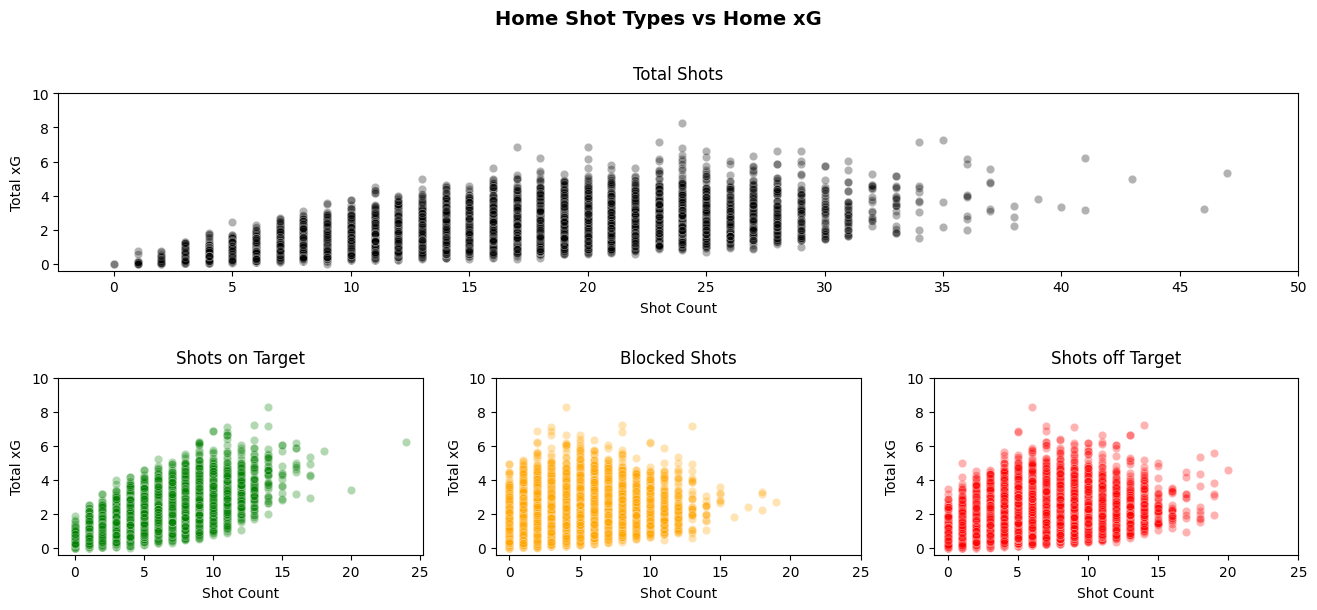

In [35]:
# Create empty grid
home_fig = plt.figure(figsize=[16,6])
home_gs = home_fig.add_gridspec(2,3)

# Assign graphs to places on the grid
h_ax1 = home_fig.add_subplot(home_gs[0,:])
h_ax2 = home_fig.add_subplot(home_gs[1,0])
h_ax3 = home_fig.add_subplot(home_gs[1,1])
h_ax4 = home_fig.add_subplot(home_gs[1,2])


# Create Total Shots vs xG, assign to h_ax1
sns.scatterplot(
    x = match_events["home_total_shot"],
    y = match_events["home_xG"],
    color="black",
    alpha=0.3,
    ax=h_ax1
)
h_ax1.set_title(
    "Total Shots",
    fontsize=12,
    pad=10
)
h_ax1.set_xlabel(
    "Shot Count",
    fontsize=10,
    labelpad=5
)
h_ax1.set_xticks(
    np.arange(0,51,5)
)
h_ax1.set_ylabel(
    "Total xG",
    fontsize=10,
    labelpad=5
)
h_ax1.set_yticks(
    np.arange(0,11,2)
)







# Create Shots on Target vs xG, assign to h_ax2
sns.scatterplot(
    x = match_events["home_shot_on_target"],
    y = match_events["home_xG"],
    color="green",
    alpha=0.3,
    ax=h_ax2
)
h_ax2.set_title(
    "Shots on Target",
    fontsize=12,
    pad=10
)
h_ax2.set_xlabel(
    "Shot Count",
    fontsize=10,
    labelpad=5
)
h_ax2.set_xticks(
    np.arange(0,26,5)
)
h_ax2.set_ylabel(
    "Total xG",
    fontsize=10,
    labelpad=5
)
h_ax2.set_yticks(
    np.arange(0,11,2)
)




# Create Blocked Shots vs xG, assign to h_ax3
sns.scatterplot(
    x = match_events["home_blocked_shot"],
    y = match_events["home_xG"],
    color="orange",
    alpha=0.3,
    ax=h_ax3
)
h_ax3.set_title(
    "Blocked Shots",
    fontsize=12,
    pad=10
)
h_ax3.set_xlabel(
    "Shot Count",
    fontsize=10,
    labelpad=5
)
h_ax3.set_xticks(
    np.arange(0,26,5)
)
h_ax3.set_ylabel(
    "Total xG",
    fontsize=10,
    labelpad=5
)
h_ax3.set_yticks(
    np.arange(0,11,2)
)




# Create Shots off Target vs xG, assign to h_ax4
sns.scatterplot(
    x = match_events["home_shot_off_target"],
    y = match_events["home_xG"],
    color="red",
    alpha=0.3,
    ax=h_ax4
)
h_ax4.set_title(
    "Shots off Target",
    fontsize=12,
    pad=10
)
h_ax4.set_xlabel(
    "Shot Count",
    fontsize=10,
    labelpad=5
)
h_ax4.set_xticks(
    np.arange(0,26,5)
)
h_ax4.set_ylabel(
    "Total xG",
    fontsize=10,
    labelpad=5
)
h_ax4.set_yticks(
    np.arange(0,11,2)
)





# Add Title
plt.suptitle(
    "Home Shot Types vs Home xG",
    fontsize=14,
    fontweight="bold",
    y=1.02
)




# Show plot
plt.subplots_adjust(
    hspace=0.6
)
plt.show()

The scatter plots indicate a clear positive relationship between home expected goals (xG) and both total shots and shots on target. As the number of shots increases, home xG generally increases, with shots on target exhibiting the strongest and most consistent association with expected goals. Total shots display a similar pattern, although the relationship becomes less pronounced at higher shot counts.

Blocked shots and shots off target appear to behave differently. In both cases the point cloud rises initially and then seems to fall away beyond roughly 5–10 shots, which would suggest that accumulating lower-quality attempts stops adding to xG past a certain point. This apparent turning point is examined directly in section 4.1.3, as scatter plots become unreliable in regions where observations are sparse.

An inspection of the most extreme shot observation revealed that Atalanta recorded **47 shots** and accumulated **5.06 xG** at home to Empoli, yet the match finished **0–0**. External match records confirm this unusual outcome (https://www.sofascore.com/football/match/empoli-atalanta/Ldbsfeb#id:7901164,tab:statistics), highlighting that exceptionally high shot volume and expected goals do not always translate into goals because of the inherent variability in finishing and goalkeeping performance.

To quantify how unusual this result was, a Skellam distribution was used with the observed xG values (5.06 vs 0.22) as Poisson means. The model estimated that, given each team obtained these xG values, there was a **98.5% probability of an Atalanta win**, a **1.3% probability of a draw**, and a **0.2% probability of an Empoli win**, indicating that the observed 0–0 result was highly unlikely under this probabilistic framework. The full methodology and calculations are provided in **Appendix 4.1.1**.

> ### 4.1.2 - Away

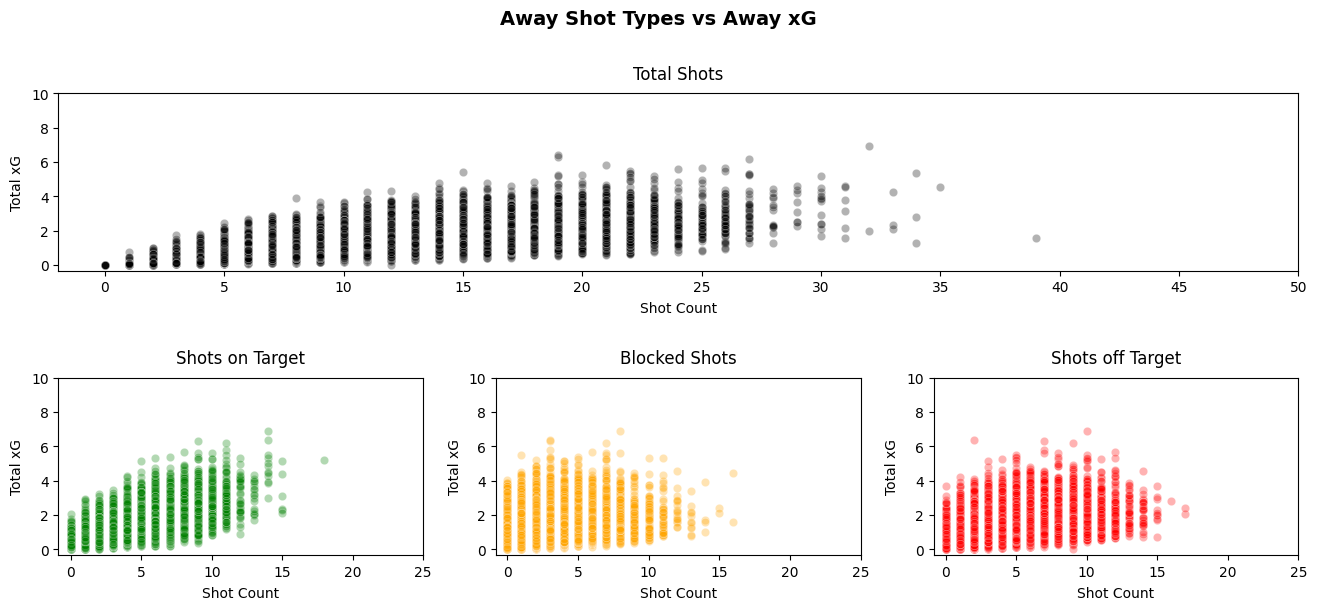

In [36]:
# Create empty grid
away_fig = plt.figure(figsize=[16,6])
away_gs = away_fig.add_gridspec(2,3)

# Assign graphs to places on the grid
a_ax1 = away_fig.add_subplot(away_gs[0,:])
a_ax2 = away_fig.add_subplot(away_gs[1,0])
a_ax3 = away_fig.add_subplot(away_gs[1,1])
a_ax4 = away_fig.add_subplot(away_gs[1,2])




# Create Total Shots vs xG, assign to a_ax1
sns.scatterplot(
    x = match_events["away_total_shot"],
    y = match_events["away_xG"],
    color="black",
    alpha=0.3,
    ax=a_ax1
)
a_ax1.set_title(
    "Total Shots",
    fontsize=12,
    pad=10
)
a_ax1.set_xlabel(
    "Shot Count",
    fontsize=10,
    labelpad=5
)
a_ax1.set_xticks(
    np.arange(0,51,5)
)
a_ax1.set_ylabel(
    "Total xG",
    fontsize=10,
    labelpad=5
)
a_ax1.set_yticks(
    np.arange(0,11,2)
)







# Create Shots on Target vs xG, assign to a_ax2
sns.scatterplot(
    x = match_events["away_shot_on_target"],
    y = match_events["away_xG"],
    color="green",
    alpha=0.3,
    ax=a_ax2
)
a_ax2.set_title(
    "Shots on Target",
    fontsize=12,
    pad=10
)
a_ax2.set_xlabel(
    "Shot Count",
    fontsize=10,
    labelpad=5
)
a_ax2.set_xticks(
    np.arange(0,26,5)
)
a_ax2.set_ylabel(
    "Total xG",
    fontsize=10,
    labelpad=5
)
a_ax2.set_yticks(
    np.arange(0,11,2)
)




# Create Blocked Shots vs xG, assign to a_ax3
sns.scatterplot(
    x = match_events["away_blocked_shot"],
    y = match_events["away_xG"],
    color="orange",
    alpha=0.3,
    ax=a_ax3
)
a_ax3.set_title(
    "Blocked Shots",
    fontsize=12,
    pad=10
)
a_ax3.set_xlabel(
    "Shot Count",
    fontsize=10,
    labelpad=5
)
a_ax3.set_xticks(
    np.arange(0,26,5)
)
a_ax3.set_ylabel(
    "Total xG",
    fontsize=10,
    labelpad=5
)
a_ax3.set_yticks(
    np.arange(0,11,2)
)




# Create Shots off Target vs xG, assign to a_ax4
sns.scatterplot(
    x = match_events["away_shot_off_target"],
    y = match_events["away_xG"],
    color="red",
    alpha=0.3,
    ax=a_ax4
)
a_ax4.set_title(
    "Shots off Target",
    fontsize=12,
    pad=10
)
a_ax4.set_xlabel(
    "Shot Count",
    fontsize=10,
    labelpad=5
)
a_ax4.set_xticks(
    np.arange(0,26,5)
)
a_ax4.set_ylabel(
    "Total xG",
    fontsize=10,
    labelpad=5
)
a_ax4.set_yticks(
    np.arange(0,11,2)
)





# Add Title
plt.suptitle(
    "Away Shot Types vs Away xG",
    fontsize=14,
    fontweight="bold",
    y=1.02
)




# Show plot
plt.subplots_adjust(
    hspace=0.6
)
plt.show()

The scatter plots indicate that the relationships between away expected goals (xG) and the four shot metrics closely mirror those observed for home teams. Away xG exhibits a clear positive relationship with both total shots and shots on target, with shots on target again displaying the strongest and most consistent association with expected goals. Total shots follow a similar pattern, although the relationship becomes less pronounced at higher shot counts. Overall, away teams tend to record slightly fewer shots and lower xG values than home teams, although the underlying relationships remain largely consistent. As was the case with the home team analysis, blocked shots and shots off target appear to rise and then fall away beyond roughly 5–10 shots.

> ### 4.1.3 - Validating Scatter Shapes

The scatter plots in 4.1.1 and 4.1.2 suggest that xG rises with blocked shots and shots off target before falling away at higher counts. Before accepting that, it is worth considering how a scatter plot behaves once observations become sparse.

Each point represents a single match. Where a shot count is common there are thousands of points, so the cloud reaches the highest xG values that occur at that count. Where a shot count is rare and there are only a handful of points, the chance of any one of them being extreme is small. The upper edge of the cloud therefore falls away simply because there are fewer opportunities for a high value to appear. It may look like a genuine decline, but it is more an illusion created by the lack of extremes.

To separate the two explanations, shot counts are grouped into intervals of three and the **mean** xG within each interval is calculated, alongside the number of matches supporting it. Averaging removes the dependence on extreme individual values, and reporting the match count makes the sparse regions explicit.

For each shot metric, every match is assigned to an interval by rounding its shot count down to the nearest multiple of three, and the mean xG and match count within each interval are then recorded. It is less about extracting exact values from this approach, and more about observing trends.

In [37]:
# Width of each shot count interval
interval_width = 3
    
# Create the home table interval
home_table = pd.DataFrame()

# Total shots

# Round each shot count down to the start of its interval.
interval = (match_events["home_total_shot"] // interval_width) * interval_width

home_table["Total Shots - Mean xG"] = match_events.groupby(interval)["home_xG"].mean().round(3)
home_table["Total Shots - Matches"] = match_events.groupby(interval)["home_xG"].count()


# Shots on target
interval = (match_events["home_shot_on_target"] // interval_width) * interval_width

home_table["Shots on Target - Mean xG"] = match_events.groupby(interval)["home_xG"].mean().round(3)
home_table["Shots on Target - Matches"] = match_events.groupby(interval)["home_xG"].count()


# Blocked shots
interval = (match_events["home_blocked_shot"] // interval_width) * interval_width

home_table["Blocked Shots - Mean xG"] = match_events.groupby(interval)["home_xG"].mean().round(3)
home_table["Blocked Shots - Matches"] = match_events.groupby(interval)["home_xG"].count()


# Shots off target
interval = (match_events["home_shot_off_target"] // interval_width) * interval_width

home_table["Shots off Target - Mean xG"] = match_events.groupby(interval)["home_xG"].mean().round(3)
home_table["Shots off Target - Matches"] = match_events.groupby(interval)["home_xG"].count()

# Replace NaN intervals with 0 to avoid error
home_table["Total Shots - Matches"] = home_table["Total Shots - Matches"].fillna(0).astype(int)
home_table["Shots on Target - Matches"] = home_table["Shots on Target - Matches"].fillna(0).astype(int)
home_table["Blocked Shots - Matches"] = home_table["Blocked Shots - Matches"].fillna(0).astype(int)
home_table["Shots off Target - Matches"] = home_table["Shots off Target - Matches"].fillna(0).astype(int)


# Add label for each interval
shot_ranges = []

for interval_start in home_table.index:
    shot_ranges.append(str(interval_start) + "-" + str(interval_start + interval_width - 1))


# Name the index and add the labels as the first column
home_table.index.name = "Interval Start"
home_table.insert(0, "Shot Range", shot_ranges)


# Ignore sample sizes smaller than 20
min_sample = 20

# Total Shots
home_table["Total Shots - Mean xG"] = np.where(home_table["Total Shots - Matches"] >= min_sample, home_table["Total Shots - Mean xG"], "-")
home_table["Total Shots - Matches"] = np.where(home_table["Total Shots - Matches"] >= min_sample, home_table["Total Shots - Matches"], "-")

# Shots on Target
home_table["Shots on Target - Mean xG"] = np.where(home_table["Shots on Target - Matches"] >= min_sample, home_table["Shots on Target - Mean xG"], "-")
home_table["Shots on Target - Matches"] = np.where(home_table["Shots on Target - Matches"] >= min_sample, home_table["Shots on Target - Matches"], "-")

# Blocked shots
home_table["Blocked Shots - Mean xG"] = np.where(home_table["Blocked Shots - Matches"] >= min_sample, home_table["Blocked Shots - Mean xG"], "-")
home_table["Blocked Shots - Matches"] = np.where(home_table["Blocked Shots - Matches"] >= min_sample, home_table["Blocked Shots - Matches"], "-")

# Shots off Target
home_table["Shots off Target - Mean xG"] = np.where(home_table["Shots off Target - Matches"] >= min_sample, home_table["Shots off Target - Mean xG"], "-")
home_table["Shots off Target - Matches"] = np.where(home_table["Shots off Target - Matches"] >= min_sample, home_table["Shots off Target - Matches"], "-")



home_table

,Shot Range,Total Shots - Mean xG,Total Shots - Matches,Shots on Target - Mean xG,Shots on Target - Matches,Blocked Shots - Mean xG,Blocked Shots - Matches,Shots off Target - Mean xG,Shots off Target - Matches
Interval Start,,,,,,,,,
0,0-2,0.175,48,0.79,4073,1.307,7808,1.065,2389
3,3-5,0.507,648,1.357,9682,1.578,9106,1.372,8521
6,6-8,0.825,2436,2.017,5206,1.863,3031,1.686,6707
9,9-11,1.135,4353,2.801,1388,2.237,557,2.006,2410
12,12-14,1.46,4768,3.666,238,2.483,103,2.301,501
15,15-17,1.781,3780,4.535,27,-,-,2.409,74
18,18-20,2.089,2330,-,-,-,-,-,-
21,21-23,2.4,1292,-,-,-,-,-,-
24,24-26,2.736,559,-,-,-,-,-,-


In [38]:
# Build away tabel

away_table = pd.DataFrame()


#  Total shots
interval = (match_events["away_total_shot"] // interval_width) * interval_width

away_table["Total Shots - Mean xG"] = match_events.groupby(interval)["away_xG"].mean().round(3)
away_table["Total Shots - Matches"] = match_events.groupby(interval)["away_xG"].count()


# Shots on target
interval = (match_events["away_shot_on_target"] // interval_width) * interval_width

away_table["Shots on Target - Mean xG"] = match_events.groupby(interval)["away_xG"].mean().round(3)
away_table["Shots on Target - Matches"] = match_events.groupby(interval)["away_xG"].count()


# Blocked shots
interval = (match_events["away_blocked_shot"] // interval_width) * interval_width

away_table["Blocked Shots - Mean xG"] = match_events.groupby(interval)["away_xG"].mean().round(3)
away_table["Blocked Shots - Matches"] = match_events.groupby(interval)["away_xG"].count()


# Shots off target
interval = (match_events["away_shot_off_target"] // interval_width) * interval_width

away_table["Shots off Target - Mean xG"] = match_events.groupby(interval)["away_xG"].mean().round(3)
away_table["Shots off Target - Matches"] = match_events.groupby(interval)["away_xG"].count()


# Replace NaN intervals with 0 to avoid error
away_table["Total Shots - Matches"] = away_table["Total Shots - Matches"].fillna(0).astype(int)
away_table["Shots on Target - Matches"] = away_table["Shots on Target - Matches"].fillna(0).astype(int)
away_table["Blocked Shots - Matches"] = away_table["Blocked Shots - Matches"].fillna(0).astype(int)
away_table["Shots off Target - Matches"] = away_table["Shots off Target - Matches"].fillna(0).astype(int)


# Add label for each interval
shot_ranges = []

for start in away_table.index:
    shot_ranges.append(str(start) + "-" + str(start + interval_width - 1))


# Name the index and add the labels as the first column
away_table.index.name = "Interval Start"
away_table.insert(0, "Shot Range", shot_ranges)


# Ignore sample sizes smaller than 20
min_sample = 20

# Total Shots
away_table["Total Shots - Mean xG"] = np.where(away_table["Total Shots - Matches"] >= min_sample, away_table["Total Shots - Mean xG"], "-")
away_table["Total Shots - Matches"] = np.where(away_table["Total Shots - Matches"] >= min_sample, away_table["Total Shots - Matches"], "-")

# Shots on Target
away_table["Shots on Target - Mean xG"] = np.where(away_table["Shots on Target - Matches"] >= min_sample, away_table["Shots on Target - Mean xG"], "-")
away_table["Shots on Target - Matches"] = np.where(away_table["Shots on Target - Matches"] >= min_sample, away_table["Shots on Target - Matches"], "-")

# Blocked shots
away_table["Blocked Shots - Mean xG"] = np.where(away_table["Blocked Shots - Matches"] >= min_sample, away_table["Blocked Shots - Mean xG"], "-")
away_table["Blocked Shots - Matches"] = np.where(away_table["Blocked Shots - Matches"] >= min_sample, away_table["Blocked Shots - Matches"], "-")

# Shots off Target
away_table["Shots off Target - Mean xG"] = np.where(away_table["Shots off Target - Matches"] >= min_sample, away_table["Shots off Target - Mean xG"], "-")
away_table["Shots off Target - Matches"] = np.where(away_table["Shots off Target - Matches"] >= min_sample, away_table["Shots off Target - Matches"], "-")

away_table

,Shot Range,Total Shots - Mean xG,Total Shots - Matches,Shots on Target - Mean xG,Shots on Target - Matches,Blocked Shots - Mean xG,Blocked Shots - Matches,Shots off Target - Mean xG,Shots off Target - Matches
Interval Start,,,,,,,,,
0,0-2,0.181,206,0.658,6351,1.02,10234,0.862,4161
3,3-5,0.458,1682,1.203,9873,1.313,8152,1.136,9799
6,6-8,0.763,4257,1.876,3673,1.659,1933,1.442,5201
9,9-11,1.058,5369,2.652,645,1.874,261,1.806,1258
12,12-14,1.39,4379,3.409,68,2.114,33,2.148,185
15,15-17,1.694,2644,-,-,-,-,-,-
18,18-20,2.013,1220,-,-,-,-,-,-
21,21-23,2.388,565,-,-,-,-,-,-
24,24-26,2.544,210,-,-,-,-,-,-


**The apparent decline does appear to be a result of sparse data.** Once shot counts of sufficient sample sizes are grouped into intervals and averaged, mean xG rises across the whole range for all four shot metrics, for both home and away teams. There is no point at which additional shots of any type stop contributing to expected goals.

Intervals supported by fewer than 20 matches are removed from the tables to prevent misleading conclusions being drawn. 

**Home teams outperform away teams at equivalent shot counts.** At every comparable interval the average home xG values sit above their away counterpart. The gap is modest but consistent across all four metrics, indicating that home advantage appears not only in the volume of shots taken but in their average quality.

**Implication for the modelling.** Since the increase in xG across intervals grows at a roughly even rate, it would seem as if every relationship is  approximately linear. Therefore, linear models are a reasonable starting point for section 5.

### 4.2 - Home vs Away

> ### 4.2.1 - xG

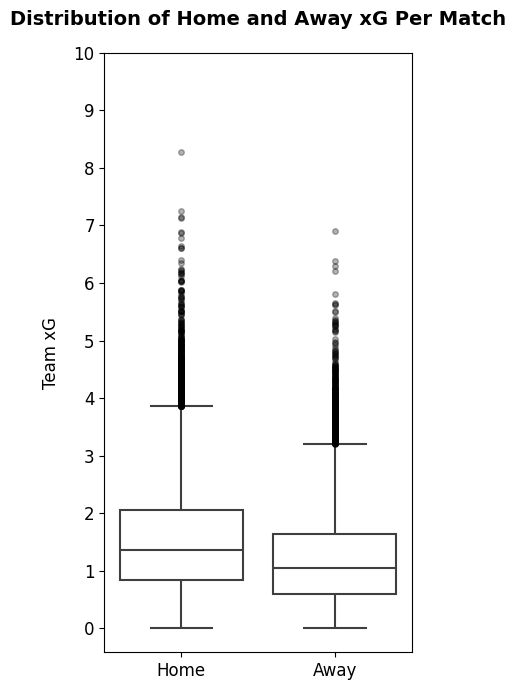

In [39]:
# Define figure size
fig, ax = plt.subplots(figsize=(4,7))

# Create Box Plot
sns.boxplot(
    data=match_events[["home_xG", "away_xG"]],
    ax=ax,
    color="white",
    linewidth=1.5,
    flierprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": 4,
        "alpha": 0.3
    }
)


# x-axis
ax.set_xticks([0, 1])
ax.set_xticklabels(
    ["Home", "Away"],
    fontsize=12
)
# y-axis
ax.set_ylabel(
    "Team xG",
    fontsize=12,
    labelpad=10
)
ax.set_yticks(
    np.arange(0,11,1)
)
ax.tick_params(
    axis="y",
    labelsize=12
)

# Add title
ax.set_title(
    "Distribution of Home and Away xG Per Match",
    fontsize=14,
    fontweight="bold",
    pad=20
)

# Show plot
plt.tight_layout()
plt.show()

The box plot reinforces the patterns identified in the scatter plots. Home teams generally produce higher xG than away teams, reflected by the higher median and upper quartile.

The interquartile ranges are broadly similar, indicating that match-to-match variation in xG is comparable for both home and away teams.

Both distributions show evidence of right-skew, with numerous high-xG outliers. This suggests that while most teams generate between approximately 1-2 xG per match, exceptionally strong attacking performances do occur, albeit less frequently.

> ### 4.2.2 - Shot Types

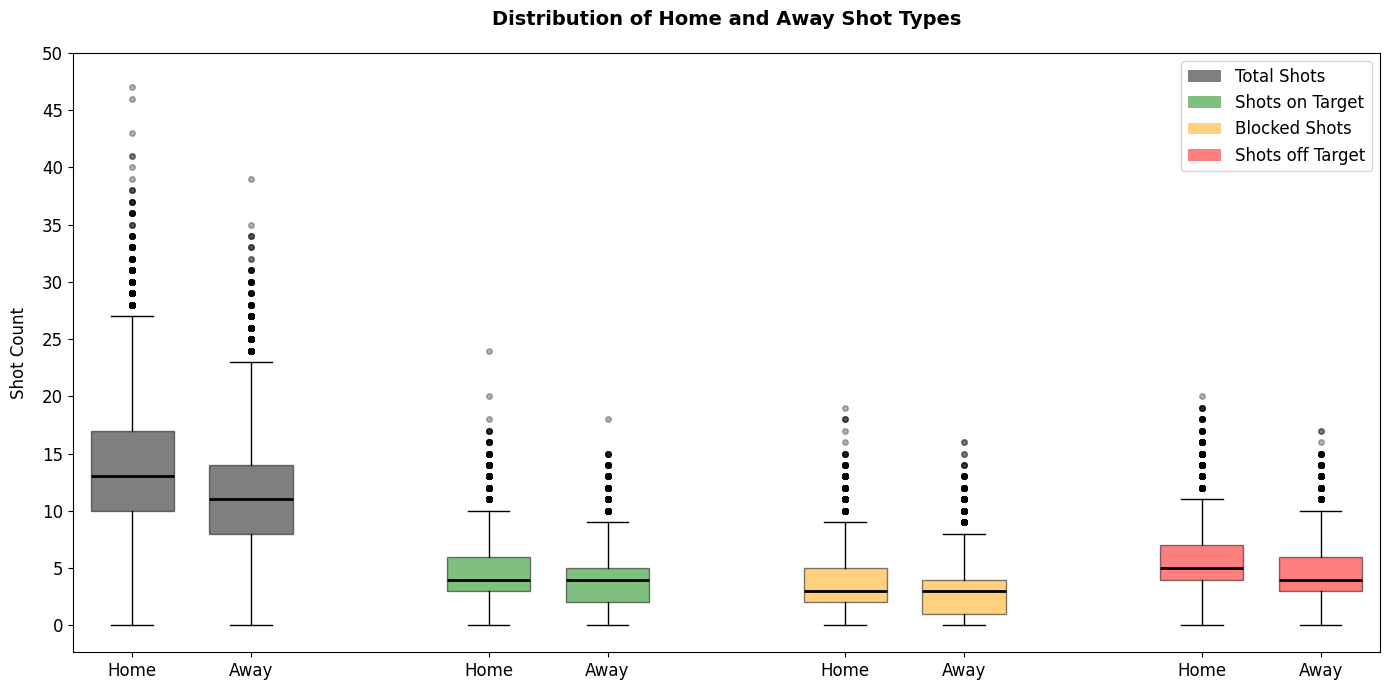

In [40]:
# Define figure size
fig, ax = plt.subplots(figsize=(14,7))

# Create list of columns to plot
shot_data = [
    match_events["home_total_shot"],
    match_events["away_total_shot"],
    match_events["home_shot_on_target"],
    match_events["away_shot_on_target"],
    match_events["home_blocked_shot"],
    match_events["away_blocked_shot"],
    match_events["home_shot_off_target"],
    match_events["away_shot_off_target"],
]

# Space out different shot types
shot_positions = [1, 2, 4, 5, 7, 8, 10, 11]

# Create box plots
boxplot = ax.boxplot(
    shot_data,
    positions=shot_positions,
    widths=0.7,
    patch_artist=True
)

# Format features

# Box colours
box_colours = [
    "black", "black",
    "green", "green",
    "orange", "orange",
    "red", "red"
]
for box, colour in zip(boxplot["boxes"], box_colours):
    box.set_facecolor(colour)
    box.set_alpha(0.5)

# Median lines
for median in boxplot["medians"]:
    median.set_color("black")
    median.set_linewidth(2)

# Whiskers
for whisker in boxplot["whiskers"]:
    whisker.set_color("black")

# Caps
for cap in boxplot["caps"]:
    cap.set_color("black")

# Fliers
for flier in boxplot["fliers"]:
    flier.set(
        marker="o",
        markersize=4,
        markerfacecolor="black",
        alpha=0.3
    )

# x-axis
ax.set_xticks(shot_positions)
ax.set_xticklabels(
    [
        "Home", "Away",
        "Home", "Away",
        "Home", "Away",
        "Home", "Away"
    ],
    fontsize=12
)

# y-axis
ax.set_ylabel(
    "Shot Count",
    fontsize=12,
    labelpad=10
)

ax.set_yticks(
    np.arange(0, 51, 5)
)

ax.tick_params(
    axis="y",
    labelsize=12
)

# Add title
ax.set_title(
    "Distribution of Home and Away Shot Types",
    fontsize=14,
    fontweight="bold",
    pad=20
)

# Create legend
legend = [
    Patch(facecolor="black", alpha=0.5, label="Total Shots"),
    Patch(facecolor="green", alpha=0.5, label="Shots on Target"),
    Patch(facecolor="orange", alpha=0.5, label="Blocked Shots"),
    Patch(facecolor="red", alpha=0.5, label="Shots off Target")
]

ax.legend(
    handles=legend,
    loc="upper right",
    fontsize=12
)

# Show plot
plt.tight_layout()
plt.show()

The shot type box plots complement the previous scatter plots and xG box plot. Across all four shot types, home teams tend to produce slightly higher shot counts than away teams.

Total shots display the widest distribution and the greatest number of high-value outliers, reflecting the broader range of shot totals observed across matches. The remaining shot types exhibit narrower distributions, which is expected as they each represent a subset of total shots.

High-value outliers are present across all shot types, indicating that although most matches produce relatively modest shot counts, exceptionally high shooting performances do occur, regardless of shot type.

### 4.3 - xG per Shot

The sections above examine shot counts and xG separately. Because a team's xG is the sum of the scoring probabilities of its individual shots, the two are linked by a third quantity: the **average quality of the shots taken**.

This is the term the project is ultimately concerned with. If shot quality were roughly constant across matches, xG would be little more than a rescaled shot count and the two measures would carry the same information. We will plot a histogram below to verify if that is the case.

Matches in which a team recorded no shots are excluded, since xG per shot is undefined for them.

In [41]:
# Calculate xG per shot for each team in each match

# Remove matches where a team took no shots, as the ratio is undefined
shots_taken = match_events[(match_events["home_total_shot"] > 0) & (match_events["away_total_shot"] > 0)].copy()

print("Matches retained: " + str(len(shots_taken)) + " of " + str(len(match_events)))
print("")

# Average xG per shot for each side
shots_taken["home_xg_per_shot"] = (shots_taken["home_xG"] / shots_taken["home_total_shot"])

shots_taken["away_xg_per_shot"] = (shots_taken["away_xG"] / shots_taken["away_total_shot"])

# Summarise the two distributions
summary = shots_taken.loc[:, ("home_xg_per_shot", "away_xg_per_shot")].describe()

print(str(round(summary, 3)))

Matches retained: 20606 of 20617

       home_xg_per_shot  away_xg_per_shot
count         20606.000         20606.000
mean              0.112             0.107
std               0.056             0.060
min               0.000             0.000
25%               0.070             0.061
50%               0.104             0.096
75%               0.144             0.140
max               0.761             0.743


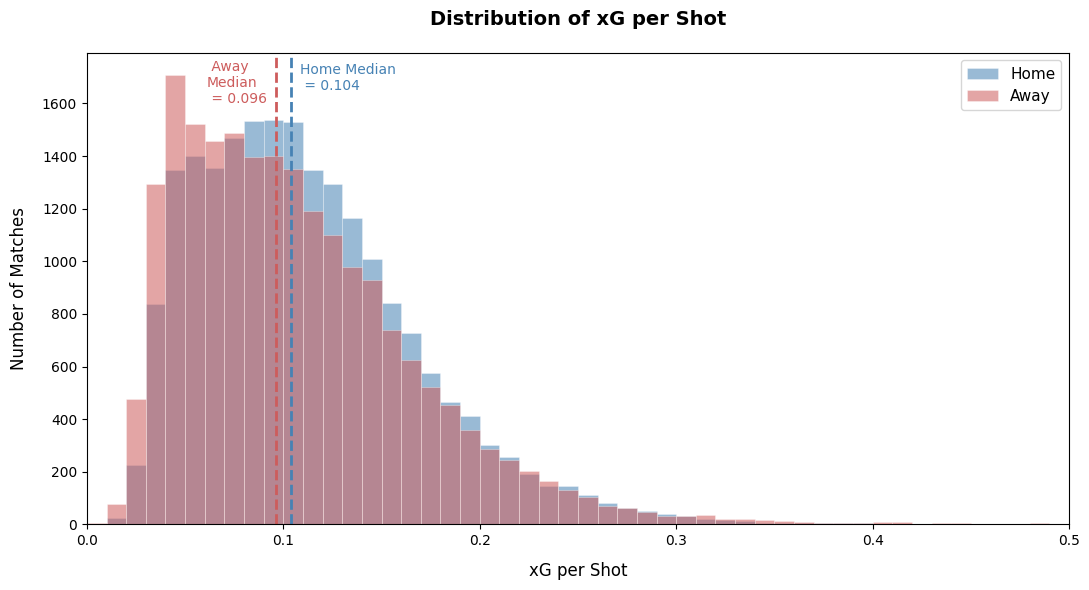

In [42]:
# Plot the distribution of xG per shot for home and away teams

fig, ax = plt.subplots(figsize=(11, 6))

# Shared bins so the two histograms are directly comparable
bins = np.arange(0, 0.51, 0.01)

# Home plot
ax.hist(
    shots_taken["home_xg_per_shot"],
    bins=bins,
    alpha=0.55,
    color="steelblue",
    label="Home",
    edgecolor="white",
    linewidth=0.4
)

# Away plot
ax.hist(
    shots_taken["away_xg_per_shot"],
    bins=bins,
    alpha=0.55,
    color="indianred",
    label="Away",
    edgecolor="white",
    linewidth=0.4
)

# Mean lines

# Home
ax.axvline(
    shots_taken["home_xg_per_shot"].median(),
    color="steelblue",
    linestyle="--",
    linewidth=2
)
ax.text(
    s="Home Median\n = " + str(round(shots_taken["home_xg_per_shot"].median(),3)),
    y=1650,
    x=shots_taken["home_xg_per_shot"].median() + 0.005,
    color="steelblue",
    fontsize=10
)

# Away
ax.axvline(
    shots_taken["away_xg_per_shot"].median(),
    color="indianred",
    linestyle="--",
    linewidth=2
)
ax.text(
    s=" Away\nMedian\n = " + str(round(shots_taken["away_xg_per_shot"].median(),3)),
    y=1600,
    x=shots_taken["away_xg_per_shot"].median() - 0.035,
    color="indianred",
    fontsize=10
)

# Title
ax.set_title(
    "Distribution of xG per Shot",
    fontsize=14,
    fontweight="bold",
    pad=20
)

# Axes
ax.set_xlabel("xG per Shot", fontsize=12, labelpad=10)
ax.set_ylabel("Number of Matches", fontsize=12, labelpad=10)
ax.set_xlim(0, 0.5)

ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

Average shot quality is far from constant. The median home shot is worth approximately **0.104 xG** and the median away shot **0.096 xG**, but the spread around those values is wide. The middle 90% of home matches ranges from **0.039 to 0.217 xG per shot**, a difference of roughly **five and a half times** between the two ends.

Two teams can therefore record identical shot counts and produce very different expected goals. A side taking fifteen speculative efforts from distance and a side engineering fifteen clear openings are indistinguishable on volume alone.

Both distributions are right-skewed, with a long upper tail representing matches built around a small number of very high-quality chances. Penalties contribute directly to this, since a penalty carries roughly 0.76 xG on its own and will lift a team's average sharply in a low-volume match.

The home and away distributions are similar in shape, with the home distribution shifted slightly right. This indicates that the home advantage observed in section 4.2 comes from **both** components of the decomposition: home teams take more shots, and their shots are also marginally better on average.

This is the variation that shot counts alone cannot capture. Section 5 quantifies how much of the total variation in xG it accounts for.

## 5 - Modelling

### 5.1 - Train/Test Split

In [43]:
# Assign train/test data
train_data, test_data = train_test_split(
    match_events,
    train_size=0.8,
    test_size=0.2,
    random_state=56
)

### 5.2 - Model Function

In [44]:
# Create function that allows us to run Linear Regression and Random Forest models on declared features and label

def regression_models(features, label):

    # Pull features and label from dataframe
    X_train = train_data[features]
    X_test = test_data[features]
    y_train = train_data[label]
    y_test = test_data[label]

    
    ###### Linear Regression ######
    # Instantiate model
    lin_reg = LinearRegression()
    
    # Fit model
    lin_reg.fit(X_train, y_train)
    
    # Predict using model
    lin_reg_xG_predict = lin_reg.predict(X_test)

    # Evaluation metrics
    # R^2
    lin_reg_r2 = lin_reg.score(X_test, y_test)   
    # MAE
    lin_reg_mae = mean_absolute_error(y_test, lin_reg_xG_predict)
    # RMSE
    lin_reg_rmse = root_mean_squared_error(y_test, lin_reg_xG_predict)
    # Coefficients
    coefficients = pd.DataFrame(
        {"Feature":features,
        "Coefficient":lin_reg.coef_.round(4)}
    )
    
    print("Linear Regression coefficients:")
    print("")
    display(coefficients)
    print("Intercept: " + str(round(lin_reg.intercept_, 4)))
    print("")
    print("")
    print("")

    
    
    ###### Random Forest ######
    # Instantiate Model
    rand_for = RandomForestRegressor(
        n_estimators=100,
        min_samples_leaf=20,
        random_state=56
    )

    # Fit model
    rand_for.fit(X_train, y_train)

    # Predict using model
    rand_for_xG_predict = rand_for.predict(X_test)

    # Evaluation metrics
    # R^2
    rand_for_r2 = rand_for.score(X_test, y_test)
    # MAE
    rand_for_mae = mean_absolute_error(y_test, rand_for_xG_predict)
    # RMSE
    rand_for_rmse = root_mean_squared_error(y_test, rand_for_xG_predict)


    
    # Create results table
    results = pd.DataFrame([
        {"Label": label,
         "# Features": len(features),
         "Model": "Linear Regression",
         "R^2": round(lin_reg_r2, 3),
         "MAE": round(lin_reg_mae, 3),
         "RMSE": round(lin_reg_rmse, 3)},

        {"Label": label,
         "# Features": len(features),
         "Model": "Random Forest",
         "R^2": round(rand_for_r2, 3),
         "MAE": round(rand_for_mae, 3),
         "RMSE": round(rand_for_rmse, 3)}
    ])

    return results

### 5.3 - Game Total Shots >>> Game xG

In [45]:
# Declare features and label
features = [
    "game_total_shot"
] 
label = "game_xG"

# Call model function
game_total = regression_models(features, label)
game_total

Linear Regression coefficients:



,Feature,Coefficient
0,game_total_shot,0.1059


Intercept: 0.0867





,Label,# Features,Model,R^2,MAE,RMSE
0,game_xG,1,Linear Regression,0.299,0.737,0.937
1,game_xG,1,Random Forest,0.295,0.739,0.939


### 5.4 - Game Shot Metrics >>> Game xG

In [46]:
# Declare features and label
features = [
    "game_shot_on_target",
    "game_blocked_shot",
    "game_shot_off_target",
] 
label = "game_xG"

# Call model function
game_shot_metrics = regression_models(features, label)
game_shot_metrics

Linear Regression coefficients:



,Feature,Coefficient
0,game_shot_on_target,0.2048
1,game_blocked_shot,0.0479
2,game_shot_off_target,0.0655


Intercept: 0.0287





,Label,# Features,Model,R^2,MAE,RMSE
0,game_xG,3,Linear Regression,0.404,0.679,0.864
1,game_xG,3,Random Forest,0.390,0.688,0.874


### 5.5 - Game Shot Metrics + Game Shot Situations >>> Game xG

`game_from_open_play` will be selected as the redundant feature to drop here, as it is the most frequently occurring shot situation in our dataframe, and gives us valuable context when analysing the other shot situations.

In [47]:
# Declare features and label
features = [
    "game_shot_on_target",
    "game_blocked_shot",
    "game_shot_off_target",
    "game_from_corner",
    "game_from_set_piece",
    "game_from_direct_fk",
    "game_from_penalty"
] 
label = "game_xG"

# Call model function
game_shot_metrics_situations = regression_models(features, label)
game_shot_metrics_situations

Linear Regression coefficients:



,Feature,Coefficient
0,game_shot_on_target,0.1893
1,game_blocked_shot,0.0506
2,game_shot_off_target,0.0689
3,game_from_corner,0.0043
4,game_from_set_piece,0.0039
5,game_from_direct_fk,-0.0617
6,game_from_penalty,0.5862


Intercept: -0.0343





,Label,# Features,Model,R^2,MAE,RMSE
0,game_xG,7,Linear Regression,0.487,0.632,0.801
1,game_xG,7,Random Forest,0.466,0.646,0.817


### 5.6 - Home Shot Metrics + Home Shot Situations >>> Home xG

`home_from_open_play` will be the redundant feature omitted, for the same reason as above.

In [48]:
# Declare features and label
features = [
    "home_shot_on_target",
    "home_blocked_shot",
    "home_shot_off_target",
    "home_from_corner",
    "home_from_set_piece",
    "home_from_direct_fk",
    "home_from_penalty"
] 
label = "home_xG"

# Call model function
home_shot_metrics_situations = regression_models(features, label)
home_shot_metrics_situations

Linear Regression coefficients:



,Feature,Coefficient
0,home_shot_on_target,0.2099
1,home_blocked_shot,0.0435
2,home_shot_off_target,0.0692
3,home_from_corner,-0.0044
4,home_from_set_piece,-0.0111
5,home_from_direct_fk,-0.0584
6,home_from_penalty,0.6000


Intercept: -0.0415





,Label,# Features,Model,R^2,MAE,RMSE
0,home_xG,7,Linear Regression,0.563,0.471,0.617
1,home_xG,7,Random Forest,0.550,0.477,0.625


### 5.7 - Away Shot Metrics + Away Shot Situations >>> Away xG

`away_from_open_play` will be the redundant feature omitted, for the same reason as above.

In [49]:
# Declare features and label
features = [
    "away_shot_on_target",
    "away_blocked_shot",
    "away_shot_off_target",
    "away_from_corner",
    "away_from_set_piece",
    "away_from_direct_fk",
    "away_from_penalty"
] 
label = "away_xG"

# Call model function
away_shot_metrics_situations = regression_models(features, label)
away_shot_metrics_situations

Linear Regression coefficients:



,Feature,Coefficient
0,away_shot_on_target,0.1996
1,away_blocked_shot,0.0475
2,away_shot_off_target,0.0703
3,away_from_corner,-0.0031
4,away_from_set_piece,-0.0009
5,away_from_direct_fk,-0.0513
6,away_from_penalty,0.6118


Intercept: -0.0689





,Label,# Features,Model,R^2,MAE,RMSE
0,away_xG,7,Linear Regression,0.568,0.400,0.535
1,away_xG,7,Random Forest,0.552,0.407,0.545


### 5.8 - Comparison & Evaluation

In [50]:
# Create table that compares the evaluation metrics for the models
all_results = pd.concat([
    game_total,
    game_shot_metrics,
    game_shot_metrics_situations,
    home_shot_metrics_situations,
    away_shot_metrics_situations
],
    ignore_index=True
)

all_results

,Label,# Features,Model,R^2,MAE,RMSE
0,game_xG,1,Linear Regression,0.299,0.737,0.937
1,game_xG,1,Random Forest,0.295,0.739,0.939
2,game_xG,3,Linear Regression,0.404,0.679,0.864
3,game_xG,3,Random Forest,0.390,0.688,0.874
4,game_xG,7,Linear Regression,0.487,0.632,0.801
5,game_xG,7,Random Forest,0.466,0.646,0.817
6,home_xG,7,Linear Regression,0.563,0.471,0.617
7,home_xG,7,Random Forest,0.550,0.477,0.625
8,away_xG,7,Linear Regression,0.568,0.400,0.535
9,away_xG,7,Random Forest,0.552,0.407,0.545


#### Model Performance

Adding information improves every metric at every stage. Working down the game-level models, R^2 rises from **0.299** with total shots alone, to **0.404** once shots are split by outcome, to **0.487** once the situation each shot arose from is included. Mean absolute error falls from **0.737** to **0.632** and root mean squared error from **0.937** to **0.801** across the same three models.

The separate home and away models achieve R^2 values of **0.563** and **0.568**, respectively. This is expected rather than surprising: a game-level model must predict the combined output of two teams, where errors on one side can offset errors on the other.

Even the strongest model leaves roughly **43% of the variation in xG unexplained**. That figure is the direct answer to the question posed in the introduction. Knowing how many shots a team took, what happened to each one, and which situation it arose from still leaves a large part of expected goals unaccounted for.

#### Linear Regression Outperforms Random Forest Throughout

Linear Regression records a higher R^2, a lower MAE and a lower RMSE than Random Forest in **all five comparisons** - fifteen out of fifteen individual metrics. That said, the margins are small - between 0.004 and 0.021 in R^2.

Random Forests are typically better at representing non-linear relationships. Its failure to beat the linear model here is consistent with the relationship between these shot metrics and xG being close to linear. That is consistent with section 4.1.3, where the mean xG at each shot count rose in an approximately constant fashion across the whole range once sparse intervals were excluded. Fortunately, the more interpretable model is also the more accurate one here.

#### One Coefficient Cannot Describe Every Shot

The clearest result in the project is the comparison between the first two models.

Section 5.3 produces a single coefficient of **0.1059**. Because total shots is the only feature, every shot in the dataset is necessarily assigned the same value, and the model has no way to distinguish a tap-in from a speculative effort.

Section 5.4 splits that single number into three:

| Shot outcome | Coefficient |
| :--- | :--- |
| On target | 0.2048 |
| Blocked | 0.0479 |
| Off target | 0.0655 |

A shot on target is worth **more than four times** a blocked shot. That spread is precisely what the single coefficient was averaging away, and it explains why R^2 rises from 0.299 to 0.404 without a single additional shot being counted. The same shots are being described more informatively.

#### Blocked Shots Rank Below Shots off Target

The ordering of the three outcome coefficients is consistent across every model that contains them: on target, then off target, then blocked. The last of these is mildly counterintuitive, since a blocked shot at least required a defender to intervene, whereas a shot off target missed the goal entirely. One possible explanation is that a block is itself evidence about the shooting position. For a shot to be blocked, a defender must be close enough to reach it, which implies a congested area and a restricted sight of goal. A shot that misses the target at least indicates the shooter likely had a clear enough view to strike it cleanly. This remains entirely a theory rather than a demonstrated cause. Whilst out of the scope of this project, the data did contain information on the shot location, which could allow us to investigate this theory further in future.

#### Separating Penalties Reveals What the Outcome Coefficients Were Hiding

Comparing sections 5.4 and 5.5 justifies our choice of giving penalties their own feature:

| Feature | 5.4 | 5.5 |
| :--- | :--- | :--- |
| Shots on target | 0.2048 | 0.1893 |
| From penalty | not included | 0.5862 |

The value attached to a shot on target **falls** once penalties are modelled separately. As calculated in the appendix, **94.1%** of penalties end up on target, so in section 5.4 the model had nowhere to record their value and absorbed part of it into the shots-on-target coefficient. Once penalties are given a feature of their own, that coefficient settles at what an ordinary shot on target is worth.

#### A Shot from a Corner is Worth About the Same as an Open Play Shot

With open play excluded as the reference category, each situation coefficient describes how much more or less a shot is worth **than an open play shot that ended the same way**. On that basis a shot from a corner is worth almost exactly the same as one from open play. The coefficient is **+0.0043** in the game-level model, but **-0.0044** for home teams and **-0.0031** for away teams. The very small coefficients and inconsistent signs across the three models suggest that the effect is negligible.

The same is true of **set pieces**, whose coefficients are **+0.0039**, **-0.0111** and **-0.0009** across the three models. 

**Direct free kicks** universally show negative coefficients across all three models (**-0.0617**, **-0.0584**, and **-0.0513**), meaning on average they exhibit lower xG values than a corresponding open play shot. One possible explanation would be that every direct free kick must be, by definition, taken outside of the box and therefore on average the shots will be coming from further away from the goal than your average open play shot. Similar to the future work we suggested for blocked shots vs shots off target, shot location data would also be beneficial here. 

Unsurprisingly, **penalties** are an order of magnitude apart, worth **0.5862 xG** more on average than an open play chance.

## 6 - Conclusion

This project set out to establish how much of a team's expected goals is explained by shot volume alone, and what the remainder can be attributed to.

#### Data Preparation and Validation

More than half a million event-level shot records were reduced to a match-level dataset of **20,617 games**. Own goals were removed, since they are recorded with 0.00 xG and do not represent attacking output. Each shot was then classified twice over, by outcome and by the situation it arose from, with both classifications attributed to the correct side.

Validating against a separate match-level dataset, total shots agreed in **99.99% of matches** for both sides. Shots on target agreed in 92.08% of matches for home teams and 93.67% for away teams, with the vast majority of disagreements amounting to a single shot. The largest single discrepancy was Cadiz against Getafe on 12 May 2024, where every reference figure was exactly double the event-level figure, pointing to the match statistics having been duplicated within the reference record rather than an error in the aggregation.

#### Exploratory Analysis

The scatter plots in section 4.1 appeared to show xG rising with blocked shots and shots off target before falling away at higher counts. Grouping shot counts into intervals and reporting the mean xG alongside the number of matches showed this to be false.

In Section 4.3, we binned xG per shot for home and away, which helped visualise the effect of home advantage. Home teams don't just generate higher xG due to increased shot counts, but also better quality chances.

#### Modelling

Five models were built, each fitted with both Linear Regression and a Random Forest and compared on R^2, MAE and RMSE against a single train/test split.

Total shots alone explain **29.9%** of the variation in game xG. Splitting by outcome raises this to **40.4%**, and adding situation raises it to **48.7%**. Modelling each side separately reaches **56.3%** for home xG and **56.8%** for away xG.

**Linear Regression outperformed the Random Forest on every metric in every comparison.** A Random Forest is better equipped to capture non-linear relationships, so its failure to outperform Linear Regression is consistent with the largely linear relationships observed in section 4.1.3. No accuracy was therefore sacrificed in order to keep a more interpretable model.

#### Findings

- **Shot counts do not tell the whole story.** A single coefficient assigns every shot a value of 0.1059. Splitting by outcome shows a shot on target is worth more than four times a blocked shot, and that distinction alone raised R^2 from 29.9% to 40.4%.

- **Two situations are exceptions.** Penalties are worth **0.5862** more than an open play shot, an order of magnitude beyond any other situation effect. Direct free kicks are worth less, at **-0.0617**, **-0.0584** and **-0.0513** across the game, home and away models, respectively. These are the only two situations with coefficients far enough from zero to indicate a tangible enough difference from an open play shot.

- **Home advantage appears in both shot volume and shot quality.** Home teams take more shots, and a home shot on target carries around 5% more xG than an away one.

- **Roughly 43% of the variation in xG remains unexplained** by the strongest model.

#### Limitations

Only shots appear in the data. A corner cleared by the goalkeeper produces no record, so nothing here can address how often a situation produces a shot in the first place, only what those shots were worth once taken.

#### Future Work

Two features in the raw event data would be interesting to investigate next.

The **`X` and `Y` coordinates** record where each shot was taken from, and were confirmed during inspection to represent position on the pitch rather than placement within the goal, since all 6,600 penalties share identical coordinates. Adding them would allow two of the interpretations offered above to be tested directly: that blocked shots come from more congested positions, and that direct free kicks are worth less than open play shots because, in general, they are taken from further out.

The **`lastAction` column** records what immediately preceded each shot, which would distinguish chances by how they were created rather than only by the situation they arose from.

## Appendix

### 4.1.1 - Home Shots vs Home xG

Predicting Atalanta's chance of beating Empoli given their post-match xG counts, using a Skellam distribution.

In [51]:
# Inspect our game with the highest home total shot count

# Columns of interest
columns_max_shot = [
    "team_h",
    "h_shot",
    "h_shotOnTarget",
    "h_xg",
    "h_goals",
    "team_a",
    "a_shot",
    "a_shotOnTarget",
    "a_xg",
    "a_goals"
]

# Data entry
general[general["h_shot"] == general["h_shot"].max()].loc[:, columns_max_shot]

,team_h,h_shot,h_shotOnTarget,h_xg,h_goals,team_a,a_shot,a_shotOnTarget,a_xg,a_goals
9193,Atalanta,47,18,5.06313,0,Empoli,3,1,0.22043,0


In [52]:
# Assign xG values to use as lambda
ata_xG = general[general["h_shot"] == general["h_shot"].max()]["h_xg"].iloc[0]
emp_xG = general[general["h_shot"] == general["h_shot"].max()]["a_xg"].iloc[0]

# Calculate match outcome probabilities
home_win = 1 - skellam.cdf(0, ata_xG, emp_xG) 
draw = skellam.pmf(0, ata_xG, emp_xG)
away_win = skellam.cdf(-1, ata_xG, emp_xG)

# Confirm our 3 outcomes sum to 100%
print("Sum of probabilities = " + str(round((home_win + draw + away_win), 6)))
print("")

# Individual outcome probabilities
print("Match outcome probabilities given attained xG values:")
print("Atalanta win: " + str(round(home_win*100, 1)) + "%")
print("Draw: " + str(round(draw*100, 1)) + "%")
print("Empoli win: " + str(round(away_win*100, 1)) + "%")
print("")
print("Outcome: Draw")

Sum of probabilities = 1.0

Match outcome probabilities given attained xG values:
Atalanta win: 98.5%
Draw: 1.3%
Empoli win: 0.2%

Outcome: Draw


### 5.8 - Comparison & Evaluation

Calculating percentage of penalties that hit the target

In [53]:
# Percentage of penalties that end up on target
penalty_shots = events[events["from_penalty"] == 1]

print("Penalties on target: " + str(round(penalty_shots["shot_on_target"].mean() * 100, 1)) + "%")

Penalties on target: 94.1%
